In [148]:
import numpy as np
import random as rnd
import pandas as pd
import string as strs
from math import *

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import pearsonr
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi
#scipy chi
from scipy.stats import chi,chi2_contingency,chi2


import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Pkg import Date Time
import time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd

import csv

# Graph Plot Packg
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns

###################################################
'''State-models'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.stattools import durbin_watson
from patsy import dmatrices
from statsmodels.stats.outliers_influence import OLSInfluence
###################################################
'''sciket-learn'''
###################################################
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import StratifiedKFold
from zlib import crc32
import hashlib

###################################################
'''scikit-lern Data Set'''
###################################################
from sklearn.datasets import fetch_openml
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.datasets import load_iris

###################################################
'''Tenser flow packeges'''
###################################################
#import tensorflow as tf
#from tensorflow import keras

###################################################
'''Miscellaneous'''
###################################################
import tarfile
import urllib.request

import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'C:\Users\TODO\Desktop\Abhi\AI\AI\Math\Hands-On\statemodelsStudy')
from olsRegressionAnalysis import dispAnalysisOfVariance, tableDispFormatt,getInvOfProductMat,\
                                  getRegressionEqn,\
                                  dispReghressionAnalysis,norm_scalling,getCorrelation,\
                                  get_variance_inflation_factors

In [ ]:
path = r'C:\Users\TODO\Desktop\Abhi\AI\AI\allDataSet\bOOK-DataSet\DeliveryTimeData.txt'
df = pd.read_csv(path)
df.columns
formula = 'DlvrTime_Y ~ NumCase_X1 + Dist_X2'
y, X = dmatrices(
                 formula_like = formula, 
                 data=df,
                 return_type='dataframe'
                 )

# 3. Model fit and summary
mod = sm.OLS(y, X)    # Describe model
res = mod.fit()       # Fit model
print(res.summary())

In [36]:
test_class = OLSInfluence(res)
dfScaledResiduals = pd.DataFrame({})
h_bar = 2 * (res.df_model + 1) / res.nobs
dfScaledResiduals['ei'] = res.resid
dfScaledResiduals['di'] = res.resid/sqrt(res.mse_resid)
dfScaledResiduals['ri'] = test_class.resid_studentized # Studentized residuals
dfScaledResiduals['hii'] = test_class.hat_matrix_diag  # Diagonal of the hat_matrix for OLS
dfScaledResiduals['e(i)'] = test_class.resid_press #PRESS residuals or deleted Residuals
dfScaledResiduals['ti'] = test_class.resid_studentized_external # R-Student or Externaly studentized residuals; using LOOO variance 
dfScaledResiduals['stuInt'] = test_class.resid_studentized_internal #Studentized residuals using variance from OLS
dfScaledResiduals['PRESS'] = np.square(res.resid/(1 - test_class.hat_matrix_diag))
print(dfScaledResiduals)



          ei        di        ri       hii       e(i)        ti    stuInt  \
0  -5.028084 -1.542606 -1.627680  0.101802  -5.597967 -1.695629 -1.627680   
1   1.146385  0.351709  0.364843  0.070702   1.233603  0.357538  0.364843   
2  -0.049794 -0.015277 -0.016092  0.098735  -0.055249 -0.015722 -0.016092   
3   4.924354  1.510782  1.579720  0.085375   5.384013  1.639165  1.579720   
4  -0.444398 -0.136341 -0.141761  0.075010  -0.480436 -0.138565 -0.141761   
5  -0.289574 -0.088841 -0.090808  0.042867  -0.302543 -0.088737 -0.090808   
6   0.844624  0.259129  0.270425  0.081799   0.919867  0.264648  0.270425   
7   1.156605  0.354844  0.366721  0.063726   1.235327  0.359390  0.366721   
8   7.419706  2.276351  3.213763  0.498292  14.788898  4.310780  3.213763   
9   2.376413  0.729079  0.813254  0.196296   2.956826  0.806776  0.813254   
10  2.237493  0.686458  0.718080  0.086133   2.448378  0.709939  0.718080   
11 -0.593041 -0.181944 -0.193257  0.113656  -0.669086 -0.188975 -0.193257   

### Anolomy Detections

##### studentized residuals vs standardized residuals:

**Standardized residuals** are calculated ***by dividing the raw residual*** by an estimate of its **standard deviation**, while **studentized residuals** are **calculated by dividing the raw residua**l by an estimate of the standard deviation that varies from point to point, taking into account the leverage of each point.

- Standardized Residuals:
    - Calculation:Raw residual divided by an estimate of the standard deviation of the errors. 

- Studentized Residuals:
    - Calculation: Raw residual divided by an estimate of the standard deviation of the residual, taking into account the leverage of each data point. 
    
#### 1. Avrage variance of residuals [Must be const]
### Anolomy Detections
#### 1. Avrage variance of residuals [Must be const]
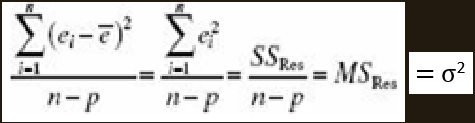

#### variance of the ith residual is
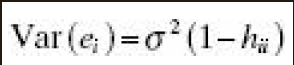

In [34]:

var_ei = res.mse_resid * (1 - test_class.hat_matrix_diag)


### PRESS STATISTIC
PRESS is generally regarded as a measure of how well a regression
model will perform in predicting new data. A model with a small
value of PRESS is desired.

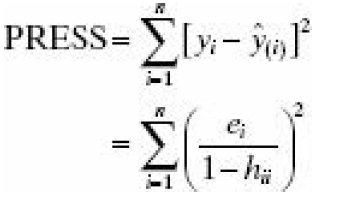

R^2 for Prediction Based on PRESS:

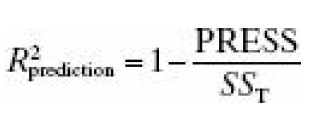

Using PRESS to Compare Models:

1. One very important use of the PRESS statistic is in 
   comparing regression models. Generally, a model with 
   a small value of PRESS is preferable to one where PRESS
   is large.

For example:
when we added x2 = distance to the regression model for the 
delivery time data containing x1 = cases, the value of
PRESS decreased from 733.55 to 457.40.
This is an indication that the two-regressor model is 
likely to be a better predictor than the model containing 
only x1 = cases.

In [35]:
summanations_of_press_statices = test_class.ess_press
print('summanations_of_press_statices: ',summanations_of_press_statices)

summanations_of_press_statices:  459.0393147025397


### Find Outliear:

hii > h_bar ==> Outliear

In [119]:
residuals_disp = False
h_bar = 2 * (res.df_model + 1) / res.nobs
outliear_standrd_res = dfScaledResiduals.loc[dfScaledResiduals['hii'] > h_bar]
index_standerd_res = outliear_standrd_res.index.values
tableDispFormatt('Outliear Index Due to Standard Residuals')
print('Standard Residuals Cutoff Points: ',h_bar,' Outliear Index are : ',outliear_standrd_res.index.values + 1)
for idx in outliear_standrd_res.index.values:
    if residuals_disp == True:
        print(dfScaledResiduals.loc[idx:idx+1,:])


=============================== Outliear Index Due to Standard Residuals ===================
Standard Residuals Cutoff Points:  0.24  Outliear Index are :  [ 9 22]


### COOK'S D DFBETA's DFFITS

In [ ]:
infl = res.get_influence()


[0.10009212912583151, 0.0033757035668747454, 9.455784608776208e-06, 0.07764718136198798, 0.0005432217444897067, 0.00012310666131130514, 0.002171604097064684, 0.0030511351819825965, 3.4193184111653587, 0.0538451604192704, 0.016199754380655924, 0.0015963916253035246, 0.0022947373736233135, 0.003292785597914907, 0.0006319879635305947, 0.0032890858851813668, 0.00040134190063827136, 0.04397807443496477, 0.011918681374630456, 0.13244490193454603, 0.05086062701291114, 0.4510454505768274, 0.02989891571556191, 0.10232239978779634, 0.00010846935173468419]


### COOK’S D

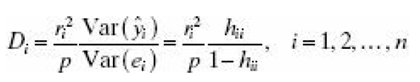

#### Using Cook's distance measures

##### Method 1: 

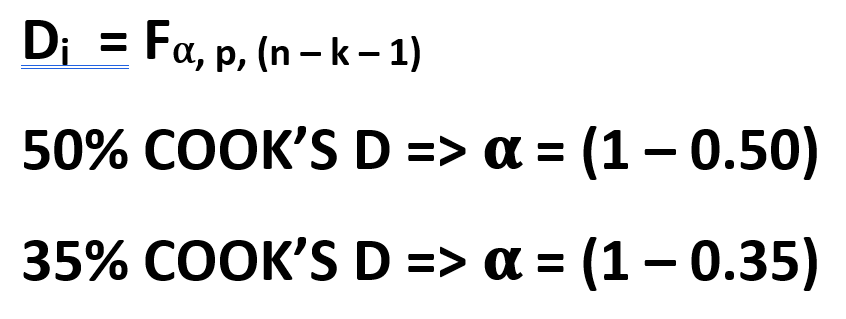

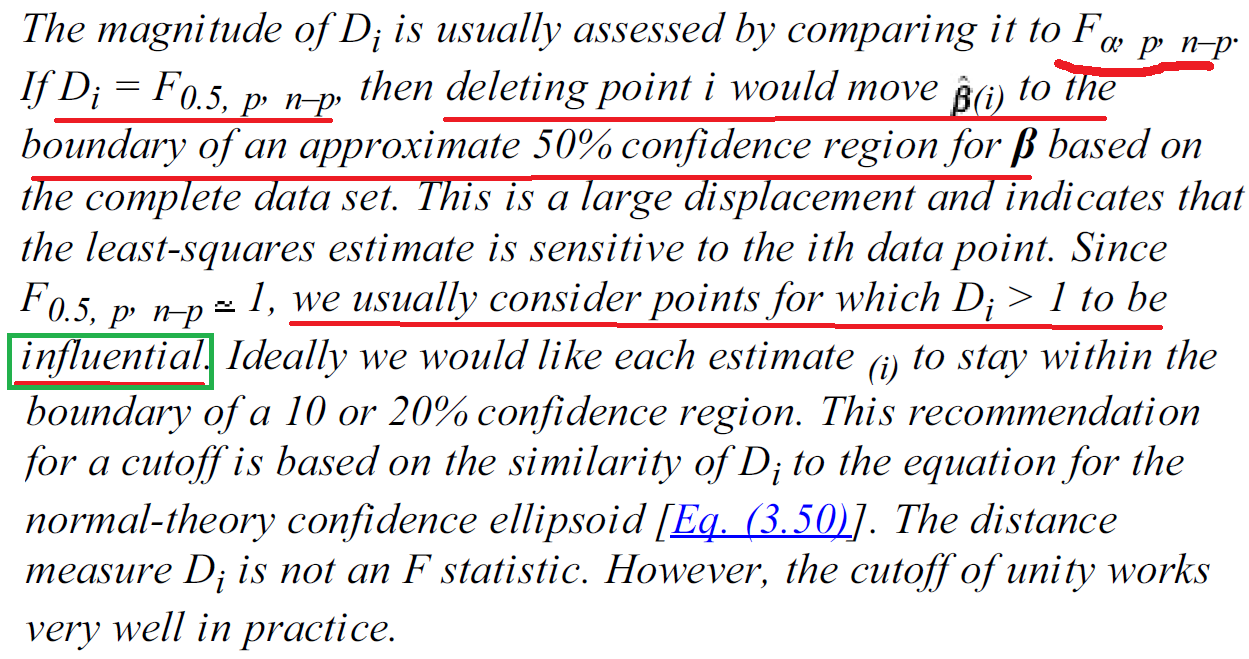

##### Method 2: Thumb rule
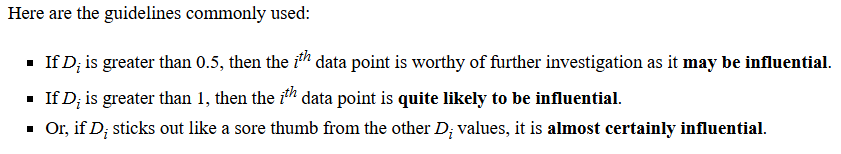

#### No Strict Cutoff:

While some suggest a cutoff of 1, others propose 4/n 
(where 'n' is the number of observations) or even 
2√k/n (where 'k' is the number of predictors). 

#### Interpreting Cook's Distance:

##### High Cook's Distance: 
  Indicates that the observation has a significant impact on the regression model's results. 
  Removing it would lead to noticeable changes in the regression coefficients and predicted 
  values. 

##### Low Cook's Distance: 
  Suggests that the observation has minimal influence on the model, and its removal 
  would not significantly alter the results. 

In [ ]:
tableDispFormatt('Outliear Index Due to COOKS\'D')
INFL = infl.summary_frame()['cooks_d']
COOKS_D = pd.Series(INFL.tolist())
ser = COOKS_D 
tableDispFormatt('COOKS\'D By Using Thumb Rule i.e. Method 2')
print('often considered potentially influential Index')
cook_outliear = ser.loc[ser > 1.0].index.values
print('COOK\'S D INDEX: ',cook_outliear + 1)
print('might warrant further investigation')
cook_outliear = ser.loc[ser > 0.5].index.values
print('COOK\'S D INDEX: ',cook_outliear + 1)

tableDispFormatt('COOKS\'D By Using F-State i.e. Method 1')
ssig = f.isf(q = 1 - 0.92, dfn = res.df_model,dfd = res.df_resid, loc=0, scale=1)
print('COOK\'S D Index @ 92% ',ser.loc[ser > ssig].index.values + 1)
ssig = f.isf(q = 1 - 0.35, dfn = res.df_model,dfd = res.df_resid, loc=0, scale=1)
print('COOK\'S D Index @ 35% ',ser.loc[ser > ssig].index.values + 1)

=============================== Outliear Index Due to COOKS'D ==============================
=============================== COOKS'D By Using Thumb Rule i.e. Method 2 ==================
often considered potentially influential Index
COOK'S D INDEX:  [9]
might warrant further investigation
COOK'S D INDEX:  [9]
=============================== COOKS'D By Using F-State i.e. Method 1 =====================
COOK'S D Index @ 92%  [9]
COOK'S D Index @ 35%  [ 9 22]


### DFBETASij

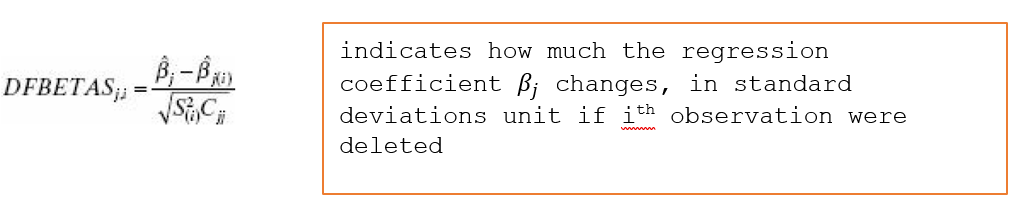

#### DFBETAS cutoff
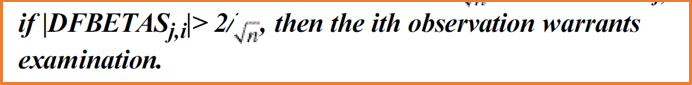

Another suggested cutoff is 0.2

In [ ]:
tableDispFormatt('Outliear Index Due to DFBETA\'S')
dfbetas_cutoff = 2/np.sqrt(res.nobs)
clm_name = (infl.summary_frame().columns.values).tolist()
dfbetas_name = []
for idx in clm_name:
    if idx == 'cooks_d':
        break
    dfbetas_name.append(idx)

DFBETAS = infl.summary_frame()[dfbetas_name]
for idx in dfbetas_name:    
    print('dfbetas index: ',DFBETAS.loc[DFBETAS[idx] > dfbetas_cutoff].index.values+1, ' due to regressor variable: ','\'',idx,'\'')



dfbetas index:  [4]  due to regressor variable:  ' dfb_Intercept '
dfbetas index:  [ 1  9 24]  due to regressor variable:  ' dfb_NumCase_X1 '
dfbetas index:  [ 9 22]  due to regressor variable:  ' dfb_Dist_X2 '


### DFFITS

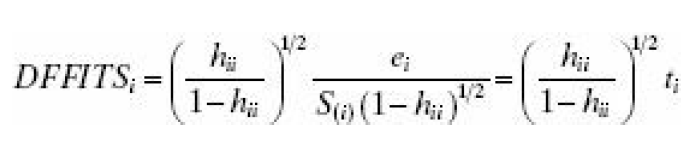

#### DFFITS Cutoff:

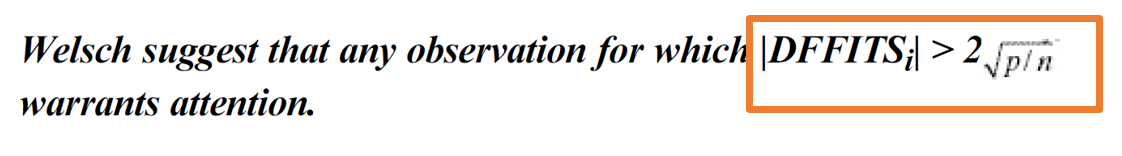


DFFITS and Cook's distance are both measures used to identify influential data points in regression analysis. They assess the impact of removing an observation on the model's fitted values. 

DFFITS focuses on the change in predicted values for a specific observation, while Cook's distance considers the overall influence of an observation on all predicted values.


In [197]:
tableDispFormatt('Outliear Index Due to DFFIT\'S')
k = res.df_model 
p = k + 1
DFFITS_cutoff = 2 * np.sqrt(p/res.nobs)
DFFITS  = infl.summary_frame()['dffits']
print('DFFITS Index ',DFFITS.loc[DFFITS > DFFITS_cutoff].index.values + 1)

=============================== Outliear Index Due to DFFIT'S ==============================
DFFITS Index  [9]


### COVRATIOi

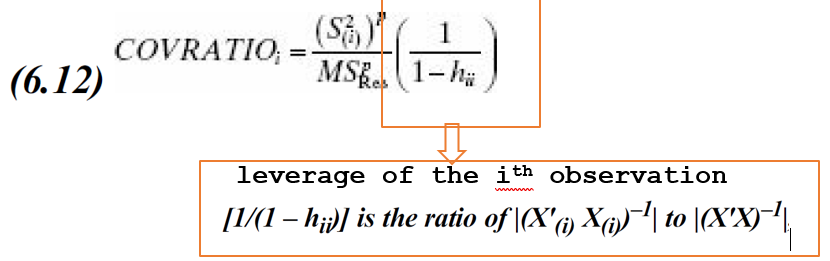

if COVRATIOi > 1, the ith observation improves the precision of estimation, 
if COVRATIOi < 1, inclusion of the ith point degrades precision.

Covariance Ratio:
A measure that considers the change in the variance-covariance matrix of the regression coefficients when an observation is removed

#### Cutoff values for COVRATIO
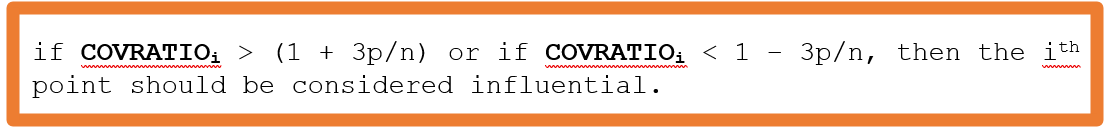

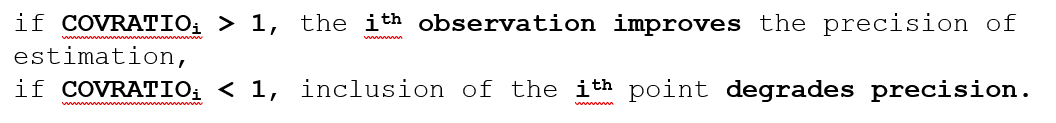

In [211]:
covratio_cutoff_upr = (1 + (3*p/res.nobs))
covratio_cutoff_lowr = (1 -(3*p/res.nobs))
cov_ser = pd.Series(test_class.cov_ratio)
print(covratio_cutoff_upr,covratio_cutoff_lowr)
print('COVRTIO Index due to upr cutoff : ',cov_ser.loc[cov_ser > covratio_cutoff_upr].index.values + 1)
print('COVRTIO Index due to lowr cutoff: ',cov_ser.loc[cov_ser < covratio_cutoff_lowr].index.values + 1)

1.3599999999999999 0.64
COVRTIO Index due to upr cutoff :  [16 22]
COVRTIO Index due to lowr cutoff:  [9]


### Get Parameter for Outliear Staticasl analysis

In [166]:
def getOutliearParam(outliearModels):
       test_class = OLSInfluence(outliearModels) # to calculate R sqr predict & Press statices
                                   # small press statices would be prefer
       dfCoff = pd.DataFrame({'coff':outliearModels.params,
                            'se err':outliearModels.bse,
                            'ci_l':outliearModels.conf_int().loc[:,0],
                            'ci_u':outliearModels.conf_int().loc[:,1]
                            },
                            index=outliearModels.params.index)
       dfANOVA = pd.DataFrame({
                            'anova': [outliearModels.nobs,outliearModels.df_model,outliearModels.df_resid,outliearModels.ssr,outliearModels.ess,outliearModels.mse_resid,
                                          outliearModels.mse_model,outliearModels.llf,outliearModels.rsquared,outliearModels.rsquared_adj,\
                                          1 - (test_class.ess_press/(outliearModels.ssr + outliearModels.ess)),test_class.ess_press]                    
                            },
                                   index=['Obs','DoFRegressors','DoFResiduals','SSres','SSr','MSres','MSr','logLike','r_sqr','r_sqr_adj',
                                          'r_sqr_predt','PRESS'])
       return dfCoff, dfANOVA
dfCoff, dfANOVA = getOutliearParam(res)
print(dfANOVA)
print(dfCoff)

                     anova
Obs              25.000000
DoFRegressors     2.000000
DoFResiduals     22.000000
SSres           233.731677
SSr            5550.810923
MSres            10.624167
MSr            2775.405461
logLike         -63.414688
r_sqr             0.959594
r_sqr_adj         0.955920
r_sqr_predt       0.920644
PRESS           459.039315
                coff    se err      ci_l      ci_u
Intercept   2.341231  1.096730  0.066752  4.615710
NumCase_X1  1.615907  0.170735  1.261825  1.969990
Dist_X2     0.014385  0.003613  0.006892  0.021878


### Outliear Analysis on the basis of Standared residuals

In [167]:
#index_standerd_res.tolist()[0]
def getStatus(x,y):
    if y > x:
        return 'Increse'
    if y < x:
        return 'Decres'
    if y == x:
        return 'NoEff'

for idx in index_standerd_res.tolist():    
    dfDropOutliear = df.drop(index = idx)
    formula = 'DlvrTime_Y ~ NumCase_X1 + Dist_X2'    
    y, X = dmatrices(
                    formula_like = formula, 
                    data=dfDropOutliear,
                    return_type='dataframe'
                    )

    # 3. Model fit and summary
    mod = sm.OLS(y, X)    # Describe model
    outliear_drop = mod.fit()       # Fit model
    dfCoff, dfANOVA['Next_'+f"{idx}"] = getOutliearParam(outliear_drop)
    #dfANOVA['status'] = dfANOVA.apply(lambda x: getStatus(x['anova'],x['Next']),axis='columns')

dfDropOutliear = df.drop(index = index_standerd_res.tolist())
formula = 'DlvrTime_Y ~ NumCase_X1 + Dist_X2'    
y, X = dmatrices(
                formula_like = formula, 
                data=dfDropOutliear,
                return_type='dataframe'
                )

# 3. Model fit and summary
mod = sm.OLS(y, X)    # Describe model
outliear_drop = mod.fit()       # Fit model
dfCoff, dfANOVA['Drop_All'] = getOutliearParam(outliear_drop)
dfANOVA

,anova,Next_8,Next_21,Drop_All
Obs,25.000000,24.000000,24.000000,23.000000
DoFRegressors,2.000000,2.000000,2.000000,2.000000
DoFResiduals,22.000000,21.000000,21.000000,20.000000
SSres,233.731677,124.002397,211.394507,123.268686
SSr,5550.810923,2293.243603,4639.643826,1204.989810
MSres,10.624167,5.904876,10.066405,6.163434
MSr,2775.405461,1146.621801,2319.821913,602.494905
logLike,-63.414688,-53.761490,-60.162592,-51.942617
r_sqr,0.959594,0.948701,0.956423,0.907195
r_sqr_adj,0.955920,0.943815,0.952273,0.897915


### MSRes Scatter Plot

<Axes: title={'center': 'Press'}>

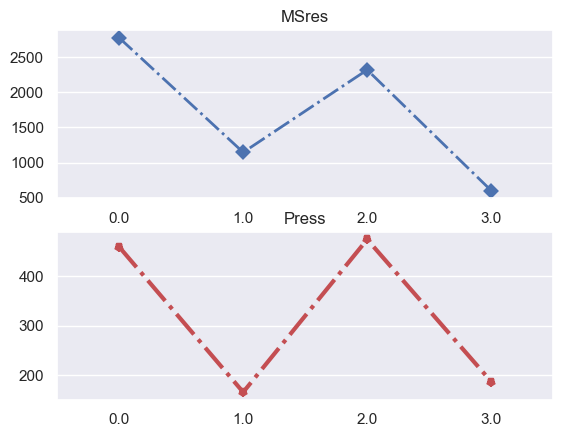

In [217]:
sns.set()
#define plotting region (2 rows, 2 columns)
fig, axes = plt.subplots(2, 1)
axes[0].set_title('MSres')
axes[1].set_title('Press')
y = dfANOVA.loc['MSr',:].values.tolist()
x = np.linspace(0,3,len(y))
sns.pointplot(x = x, y = y,markers='D',color="b",markersize=5,markeredgewidth=3,lw=2,linestyle="-.",ax=axes[0])

y = dfANOVA.loc['PRESS',:].values.tolist()
x = np.linspace(0,3,len(y))
sns.pointplot(x = x, y = y,markers='*',color="r",markersize=5,markeredgewidth=4,lw=3,linestyle="-.",ax=axes[1])

### P-P PLOT 



### Q-Q PLOT
 

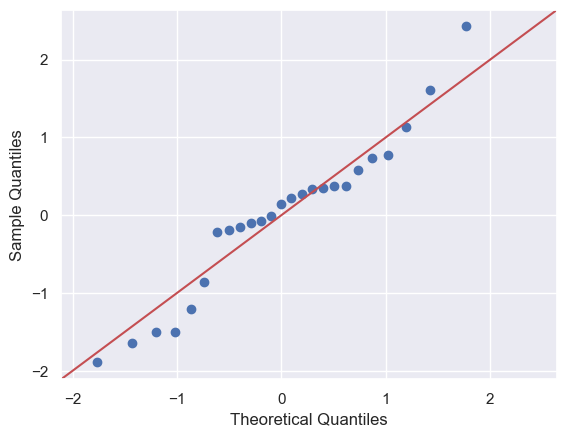

In [ ]:
# Compleate module
sm.qqplot(res.resid,line="45", fit = True)
plt.show()

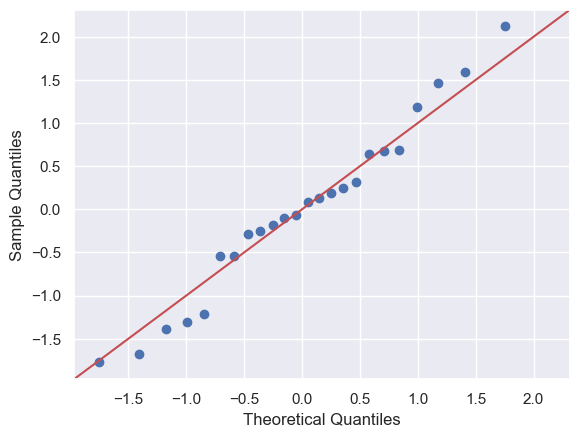

In [215]:
# Remove Outliear 9
dfDropOutliear = df.drop(index = 8)
formula = 'DlvrTime_Y ~ NumCase_X1 + Dist_X2'    
y, X = dmatrices(
                formula_like = formula, 
                data=dfDropOutliear,
                return_type='dataframe'
                )

# 3. Model fit and summary
mod = sm.OLS(y, X)    # Describe model
outliear_drop = mod.fit()       # Fit model
sm.qqplot(outliear_drop.resid,line="45", fit = True)
plt.show()

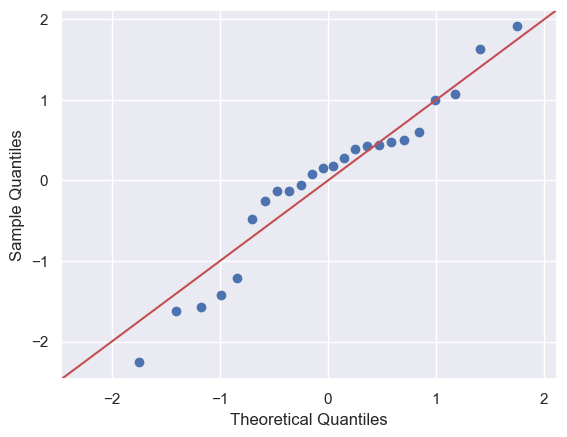

In [218]:
# Remove Outliear 21
dfDropOutliear = df.drop(index = 21)
formula = 'DlvrTime_Y ~ NumCase_X1 + Dist_X2'    
y, X = dmatrices(
                formula_like = formula, 
                data=dfDropOutliear,
                return_type='dataframe'
                )

# 3. Model fit and summary
mod = sm.OLS(y, X)    # Describe model
outliear_drop = mod.fit()       # Fit model
sm.qqplot(outliear_drop.resid,line="45", fit = True)
plt.show()

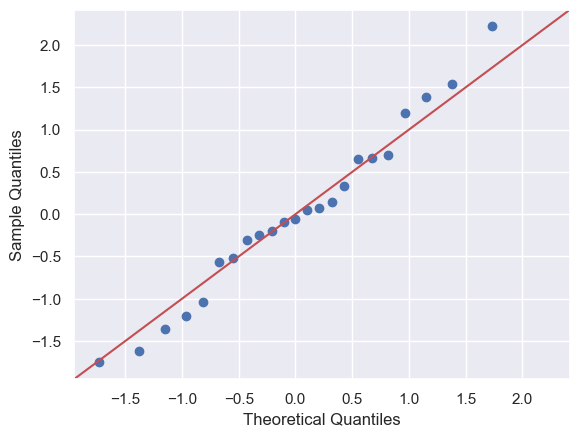

In [219]:
# Remove Outliear 9
dfDropOutliear = df.drop(index = [8,21])
formula = 'DlvrTime_Y ~ NumCase_X1 + Dist_X2'    
y, X = dmatrices(
                formula_like = formula, 
                data=dfDropOutliear,
                return_type='dataframe'
                )

# 3. Model fit and summary
mod = sm.OLS(y, X)    # Describe model
outliear_drop = mod.fit()       # Fit model
sm.qqplot(outliear_drop.resid,line="45", fit = True)
plt.show()

### P-Q PLOT